# Figures of Beo model results

This notebook is a notebook version of the `make_figure.py` script. It reads a
model output file that was generated by `beo.py` and makes two figures:

1. The modelled temperature field at a number of timeslices, with the direction
   of the fluid flux shown as arrows and the temperature at the land surface or
   the seafloor in a panel above each timeslice.
2. The temperature of the water that leaves the model domain at the top of the
   fault zone over time, which is the temperature of the hot spring or the
   submarine vent that is fed by the fault.

The second figure is not included in `make_figure.py`.

Unlike the script, this notebook does not ask any questions while it runs. All
choices are made in the settings cell below. The notebook covers the modelled
temperatures only. Figures of modelled apatite (U-Th)/He ages and of borehole
temperatures are available in `make_figure.py`.

## Modules

In [1]:
import os
import glob
import pickle
import warnings

import numpy as np
import pandas as pd
import scipy.interpolate
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import ticker

day = 24.0 * 60.0 * 60.0
year = 365.25 * day
degree_symbol = chr(176)

## Find the model output files

By default the notebook looks for the model output files in the `model_output`
directory of Beo and takes the file that was modified last. Set `model_file` to
a filename to make figures of a different model run.

In [ ]:
model_output_dir = os.path.join('..', 'model_output')

model_files = sorted(glob.glob(os.path.join(model_output_dir, '*.pck')),
                     key=os.path.getmtime)

if len(model_files) == 0:
    raise IOError('no model output files found in %s, run beo.py first'
                  % os.path.abspath(model_output_dir))

print('model output files, from oldest to newest:')
for model_file_i in model_files:
    print('   ', os.path.basename(model_file_i))

# default: use the most recent model output file, but can be changed to an older one if desired
model_file = model_files[-1]

print('')
print('making figures of %s' % os.path.basename(model_file))

model output files, from oldest to newest:
    results_model_run_0_[[-300.0]]_radial_submarine_17-8-2026.pck
    results_model_run_0_[]_radial_submarine_17-8-2026.pck

making figures of results_model_run_0_[]_radial_submarine_17-8-2026.pck


## Read the model output file

The model output file is a python pickle file that contains a single list of
model results. The order of the items in this list is the same as in
`make_figure.py`.

In [4]:
with open(model_file, 'rb') as fin:
    output_data = pickle.load(fin)

if len(output_data) != 38:
    msg = 'error, expected 38 items in the model output file but found %i. '
    msg += 'this notebook reads the output of the current version of beo.py, '
    msg += 'use make_figure.py for output files of older versions'
    raise ValueError(msg % len(output_data))

(runtimes_all, runtimes, xyz_array,
 surface_levels, x_loc_fault, z_loc_fault,
 T_init_array, T_array, boiling_temp_array,
 xyz_array_exc, exceed_boiling_temp_array, xyz_element_array,
 qh_array, qv_array, fault_fluxes,
 durations, xzs, Tzs,
 x_surface, T_surface,
 Ahe_ages_all, Ahe_ages_all_corr, xs_Ahe_all, Ahe_depths,
 AHe_ages_surface, AHe_ages_surface_corr, AHe_xcoords_surface,
 AHe_ages_samples_surface, AHe_ages_samples_surface_corr, AHe_data_file,
 borehole_xlocs, borehole_zlocs, borehole_depths,
 borehole_temp_measured, borehole_temps_modeled,
 z_borehole, he_ages_borehole, he_ages_borehole_corrected) = output_data

runtimes = np.array(runtimes)
T_array = np.array(T_array)
x_surface = np.array(x_surface)
T_surface = np.array(T_surface)
qh_array = np.array(qh_array)
qv_array = np.array(qv_array)
surface_levels = np.array(surface_levels)
x_loc_fault = np.array(x_loc_fault)

## Contents of the model output file

The number of timeslices in the output file is set by the parameter `N_outputs`
in the model parameter file, and the timeslices are taken from the timesteps
that were stored during the model run, which are controlled by `dt_stored`.

In [5]:
print('model domain from x = %0.1f to %0.1f m and from z = %0.1f to %0.1f m'
      % (xyz_array[:, 0].min(), xyz_array[:, 0].max(),
         xyz_array[:, 1].min(), xyz_array[:, 1].max()))
print('%i mesh vertices and %i cells' % (len(xyz_array), len(xyz_element_array)))
print('%i timeslices, from %0.1f to %0.1f years'
      % (len(runtimes), runtimes[0] / year, runtimes[-1] / year))

if len(runtimes) > 1:
    print('time between the timeslices: %0.1f years'
          % ((runtimes[1] - runtimes[0]) / year))
print('modelled temperatures from %0.1f to %0.1f %sC'
      % (T_array.min(), T_array.max(), degree_symbol))
print('fault zone at x = %0.1f m' % x_loc_fault[-1])

model domain from x = 0.0 to 4000.0 m and from z = -4000.0 to 2.0 m
143818 mesh vertices and 285087 cells
16 timeslices, from 0.0 to 15000.0 years
time between the timeslices: 1000.0 years
modelled temperatures from 7.7 to 131.6 °C
fault zone at x = 0.0 m


## Settings for the temperature figure

The temperature field is interpolated from the model mesh to a regular grid
before it is contoured. Only the part of the mesh that falls inside `xlim` and
`ylim` is used for this, which means that `dx` and `dy` can be much smaller than
in `make_figure.py` and that narrow features like a fault zone or a vent conduit
stay visible.

Set `xlim` or `ylim` to `None` to show the entire model domain.

In [6]:
timeslices_to_show_yr = [0, 1000, 15000]

xlim = [0, 250]
ylim = [-250, 5]

dx = 0.5
dy = 0.5

contour_interval = 1.0
contour_range = None

colormap = matplotlib.colormaps['coolwarm']

figure_size = (10.0, 6.0)
figure_resolution = 150
figure_formats = ['png', 'pdf']

arrow_scale_multiplier = 25.0
skip_arrows = 200
arrow_transparency = 0.75

outlet_profile_width = 10.0

figure_dir = 'fig'

## Select the timeslices to show

The times in `timeslices_to_show_yr` are matched to the closest timeslice in the
model output file.

In [7]:
runtimes_yr = runtimes / year

timeslices = []

for target in timeslices_to_show_yr:

    timeslice = int(np.argmin(np.abs(runtimes_yr - target)))

    if timeslice in timeslices:
        print('warning, the requested time of %0.1f years is closest to '
              'timeslice %i, which is already shown. this timeslice is left '
              'out of the figure' % (target, timeslice))
        continue

    timeslices.append(timeslice)

    print('timeslice %i at %0.1f years, closest to the requested %0.1f years'
          % (timeslice, runtimes_yr[timeslice], target))

if xlim is None:
    xlim = [xyz_array[:, 0].min(), xyz_array[:, 0].max()]

if ylim is None:
    ylim = [xyz_array[:, 1].min(), xyz_array[:, 1].max()]

timeslice 0 at 0.0 years, closest to the requested 0.0 years
timeslice 1 at 1000.0 years, closest to the requested 1000.0 years
timeslice 15 at 15000.0 years, closest to the requested 15000.0 years


## Interpolate the modelled temperatures to a regular grid

The model results are calculated on an unstructured mesh and are interpolated to
a regular grid to be able to draw filled contours. The vertices outside the
figure window are left out before interpolating, with a small margin to avoid
gaps at the edge of the figure.

In [8]:
def interpolate_to_grid(xyz, values, xlim, ylim, dx, dy, margin=0.1,
                        max_nodes=1e6):

    """
    Interpolate model results to a regular grid, using only the part of the
    model domain that is shown in the figure.

    The grid is made coarser when the chosen values of dx and dy would result
    in more than max_nodes grid nodes, which would use a lot of memory and
    would be slow. This happens when the entire model domain is shown.
    """

    x, y = xyz[:, 0], xyz[:, 1]

    margin_x = margin * (xlim[1] - xlim[0])
    margin_y = margin * (ylim[1] - ylim[0])

    selected = ((x >= xlim[0] - margin_x) & (x <= xlim[1] + margin_x)
                & (y >= ylim[0] - margin_y) & (y <= ylim[1] + margin_y))

    n_nodes = ((xlim[1] - xlim[0]) / dx) * ((ylim[1] - ylim[0]) / dy)

    if n_nodes > max_nodes:
        coarsen = np.sqrt(n_nodes / max_nodes)
        dx = dx * coarsen
        dy = dy * coarsen
        print('warning, a grid of %0.2f x %0.2f m would need %0.1e nodes for '
              'this figure window. using a grid of %0.2f x %0.2f m instead'
              % (dx / coarsen, dy / coarsen, n_nodes, dx, dy))

    xi = np.arange(xlim[0], xlim[1] + dx, dx)
    yi = np.arange(ylim[0], ylim[1] + dy, dy)

    xg, yg = np.meshgrid(xi, yi)

    zg = scipy.interpolate.griddata(xyz[selected], values[selected], (xg, yg),
                                    method='linear')

    return xg, yg, zg


print('interpolating the modelled temperatures to a grid of %0.2f x %0.2f m'
      % (dx, dy))

grids = [interpolate_to_grid(xyz_array, T_array[timeslice], xlim, ylim, dx, dy)
         for timeslice in timeslices]

print('%i by %i grid nodes for each timeslice' % (grids[0][0].shape[1],
                                                  grids[0][0].shape[0]))

interpolating the modelled temperatures to a grid of 0.50 x 0.50 m
501 by 511 grid nodes for each timeslice


## Figure of the modelled temperature field

Each column of the figure shows one timeslice. The panel at the top shows the
modelled temperature at the land surface or the seafloor, the panel below shows
the temperature in the subsurface and the direction of the fluid flux.

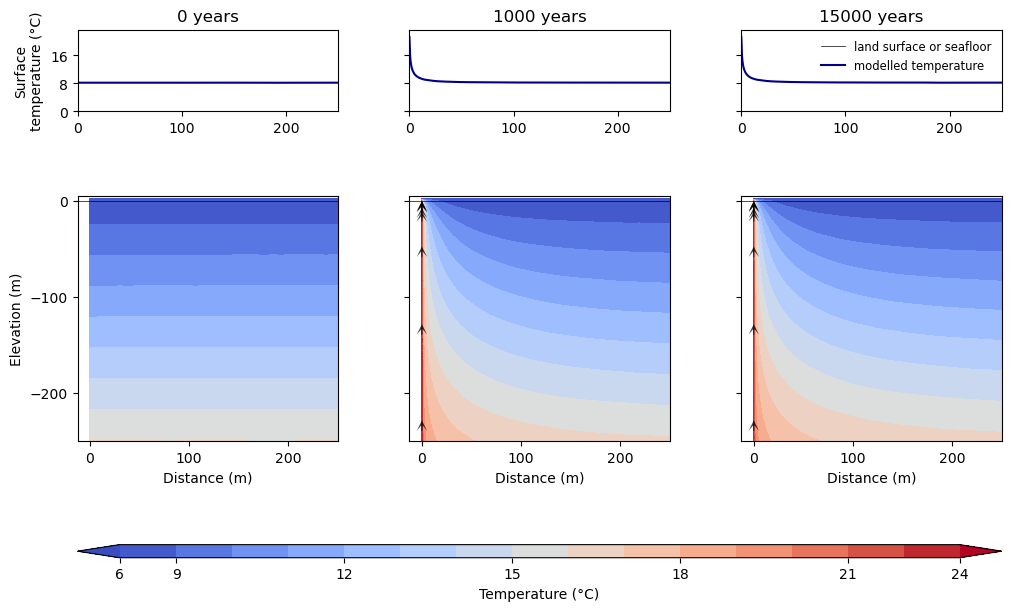

In [21]:
temperatures_shown = np.array([grid[2] for grid in grids])

if contour_range is None:
    vmin = np.nanmin(temperatures_shown)
    vmax = np.nanmax(temperatures_shown)
else:
    vmin, vmax = contour_range

contours = np.arange(vmin, vmax + contour_interval, contour_interval)

fig = plt.figure(figsize=figure_size, layout="constrained")

gs = gridspec.GridSpec(3, len(timeslices), height_ratios=[25, 75, 4], figure=fig)
gs.update(wspace=0.1, hspace=0.3)

top_panels = [fig.add_subplot(gs[0, i]) for i in range(len(timeslices))]
panels = [fig.add_subplot(gs[1, i]) for i in range(len(timeslices))]
colorbar_panel = fig.add_subplot(gs[2, :])

legend_items = []
legend_labels = []

for panel, top_panel, timeslice, (xg, yg, zg) in zip(panels, top_panels,
                                                     timeslices, grids):

    leg_cn = panel.contourf(xg, yg, zg, contours, cmap=colormap, extend='both')

    # rasterize the contours to keep the vector version of the figure small
    # matplotlib 3.10 warns that the rasterization will be ignored, this
    # warning is incorrect, the contours are rasterized by the draw method of
    # the parent class
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        leg_cn.set_rasterized(True)

    # the direction of the fluid flux, shown for the cells inside the figure
    # window that have a non zero flux
    xq = xyz_element_array[:, 0]
    yq = xyz_element_array[:, 1]
    qh = qh_array[timeslice] * year
    qv = qv_array[timeslice] * year
    flux = np.sqrt(qh ** 2 + qv ** 2)

    inside = ((xq >= xlim[0]) & (xq <= xlim[1])
              & (yq >= ylim[0]) & (yq <= ylim[1]) & (flux > 0))

    if np.any(inside):
        arrow_scale = flux[inside].max() * arrow_scale_multiplier
        panel.quiver(xq[inside][::skip_arrows], yq[inside][::skip_arrows],
                     qh[inside][::skip_arrows], qv[inside][::skip_arrows],
                     angles='xy', scale=arrow_scale, headwidth=10, headlength=10, width=0.02,
                     pivot='tip', alpha=arrow_transparency)

    leg_surf = panel.axhline(y=surface_levels[timeslice], color='black', lw=0.5)

    leg_st, = top_panel.plot(x_surface[timeslice], T_surface[timeslice],
                             color='darkblue')

    xlim_buffer = 0.05 * (xlim[1] - xlim[0])
    panel.set_xlim(xlim[0] - xlim_buffer, xlim[1])
    panel.set_ylim(ylim)
    top_panel.set_xlim(xlim)
    top_panel.set_title('%0.0f years' % runtimes_yr[timeslice])
    panel.set_xlabel('Distance (m)')

legend_items += [leg_surf, leg_st]
legend_labels += ['land surface or seafloor', 'modelled temperature']

top_temperature_max = T_surface[timeslices].max()

for top_panel in top_panels:
    top_panel.set_ylim(0, top_temperature_max * 1.1)

panels[0].set_ylabel('Elevation (m)')
top_panels[0].set_ylabel('Surface\ntemperature (%sC)' % degree_symbol)

for panel in panels[1:]:
    panel.set_yticklabels([])

for top_panel in top_panels[1:]:
    top_panel.set_yticklabels([])

for panel in panels + top_panels:
    panel.xaxis.set_major_locator(ticker.MaxNLocator(3))
    panel.yaxis.set_major_locator(ticker.MaxNLocator(3))

colorbar = fig.colorbar(leg_cn, cax=colorbar_panel, orientation='horizontal')
colorbar.locator = ticker.MaxNLocator(5)
colorbar.update_ticks()
colorbar.set_label('Temperature (%sC)' % degree_symbol)

top_panels[-1].legend(legend_items, legend_labels, loc='upper right', fontsize='small',
           frameon=False)

plt.show()

## Save the temperature figure

The figures are saved next to the notebook, in the directory given by
`figure_dir`.

In [10]:
if os.path.exists(figure_dir) is False:
    os.mkdir(figure_dir)

figure_base = os.path.splitext(os.path.basename(model_file))[0]

for figure_format in figure_formats:
    figure_file = os.path.join(figure_dir,
                               '%s_T_field.%s' % (figure_base, figure_format))
    fig.savefig(figure_file, dpi=figure_resolution, bbox_inches='tight')
    print('saved %s' % figure_file)

saved fig/results_model_run_0_[]_radial_submarine_17-8-2026_T_field.png
saved fig/results_model_run_0_[]_radial_submarine_17-8-2026_T_field.pdf


## Temperature of the water leaving the fault zone over time

The outlet temperature is the modelled temperature at the top of the fault zone,
where the water leaves the model domain. For a hot spring this is the spring
temperature and for a submarine model this is the temperature of the venting
water.

The temperature is taken from the modelled temperature at the land surface or
the seafloor, at the node that is closest to the fault zone. The location of the
fault zone is stored for each timeslice, because it moves when the model
includes exhumation.

The fault zone has a finite width, so the temperature varies over the outlet.
The value used here is the temperature at the center of the fault zone.

Check the profile in the right panel of the figure below before using the outlet
temperature. For a radially symmetric model the temperature has a clear maximum
at the symmetry axis, so the value at the fault zone is the temperature of the
venting water. For a model with exhumation the modelled temperature at the
surface varies over a distance of a few meters, which is the size of the grid
cells near the fault zone, and the temperature at the fault zone is then one of
several values that are equally valid.

In [11]:
outlet_temperatures = np.zeros(len(runtimes))
outlet_distances = np.zeros(len(runtimes))

for i in range(len(runtimes)):

    distance_to_fault = np.abs(x_surface[i] - x_loc_fault[i])
    closest = np.argmin(distance_to_fault)

    outlet_temperatures[i] = T_surface[i][closest]
    outlet_distances[i] = distance_to_fault[closest]

print('outlet temperature taken at a distance of %0.2f to %0.2f m from the '
      'fault zone' % (outlet_distances.min(), outlet_distances.max()))
print('outlet temperature from %0.1f to %0.1f %sC'
      % (outlet_temperatures.min(), outlet_temperatures.max(), degree_symbol))
print('final outlet temperature %0.1f %sC' % (outlet_temperatures[-1],
                                              degree_symbol))

outlet temperature taken at a distance of 0.00 to 0.00 m from the fault zone
outlet temperature from 8.2 to 21.2 °C
final outlet temperature 21.2 °C


## Figure of the outlet temperature over time

The left panel shows the outlet temperature over time and the right panel shows
the temperature at the surface as a function of the distance to the fault zone,
for the last timeslice.

The outlet temperature usually rises as a step at the moment that the flow in
the fault zone is switched on. This is not an artefact of the time resolution of
the figure. The water needs only a few minutes to travel up a fault zone that
discharges several litres per second, so the water that arrives at the surface
has almost the temperature of the rock at the base of the fault zone from the
first timestep onwards. The slow change after this step is caused by the heating
or cooling of the rock around the fault zone and is much smaller than the step
itself.

The number of points in the left panel is the number of timeslices in the model
output file, which is set by `N_outputs` and `dt_stored` in the model parameter
file. Lower these values to follow the slow change after the initial step in
more detail.

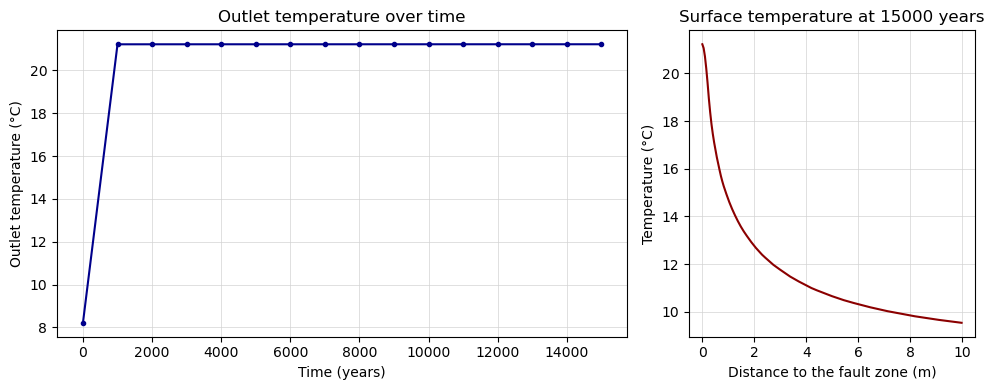

In [12]:
fig, (panel, profile_panel) = plt.subplots(1, 2, figsize=(10.0, 4.0),
                                           width_ratios=[2, 1])

panel.plot(runtimes_yr, outlet_temperatures, color='darkblue', marker='o',
           ms=3)

panel.set_xlabel('Time (years)')
panel.set_ylabel('Outlet temperature (%sC)' % degree_symbol)
panel.set_title('Outlet temperature over time')
panel.grid(color='lightgray', lw=0.5)

near_outlet = np.abs(x_surface[-1] - x_loc_fault[-1]) <= outlet_profile_width

profile_panel.plot(x_surface[-1][near_outlet] - x_loc_fault[-1],
                   T_surface[-1][near_outlet], color='darkred')

profile_panel.set_xlabel('Distance to the fault zone (m)')
profile_panel.set_ylabel('Temperature (%sC)' % degree_symbol)
profile_panel.set_title('Surface temperature at %0.0f years'
                        % runtimes_yr[-1])
profile_panel.grid(color='lightgray', lw=0.5)

fig.tight_layout()

plt.show()

## Save the outlet temperature figure and the modelled outlet temperatures

In [13]:
for figure_format in figure_formats:
    figure_file = os.path.join(figure_dir,
                               '%s_outlet_T.%s' % (figure_base, figure_format))
    fig.savefig(figure_file, dpi=figure_resolution, bbox_inches='tight')
    print('saved %s' % figure_file)

outlet_data = pd.DataFrame({'time_yr': runtimes_yr,
                            'outlet_temperature': outlet_temperatures})

outlet_file = os.path.join(figure_dir, '%s_outlet_T.csv' % figure_base)
outlet_data.to_csv(outlet_file, index=False)

print('saved %s' % outlet_file)

saved fig/results_model_run_0_[]_radial_submarine_17-8-2026_outlet_T.png
saved fig/results_model_run_0_[]_radial_submarine_17-8-2026_outlet_T.pdf
saved fig/results_model_run_0_[]_radial_submarine_17-8-2026_outlet_T.csv
